### 1. Dataset Generation
In this cell, we use `sklearn.datasets.make_classification` to generate a synthetic 2D dataset with 500 samples for binary classification.

In [34]:
from sklearn.datasets import make_classification
import random
import numpy as np
X, y = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, random_state=1)
print(X.shape, y.shape)
#

(500, 2) (500,)


### 2. Data Visualization
We visualize the generated dataset using a scatter plot to understand the distribution and overlap of the two classes.

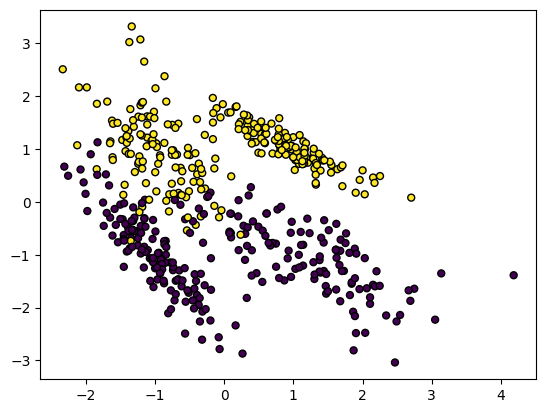

In [35]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], marker='o', c=y, s=25, edgecolor='k')
#

perceptron trick using step function


### 3. Perceptron Implementation (Step Function)
This section defines the Perceptron training logic using a discrete step function for weight updates.

In [36]:
def perceptron(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

In [37]:
def step(z):
    return 1 if z>0 else 0

### 4. Training and Coefficients
We run the perceptron algorithm on our data and extract the final intercept and coefficients.

In [38]:
intercept_,coef_ = perceptron(X,y)

In [39]:
print(coef_)
print(intercept_)

[0.10030904 1.04352919]
0.10000000000000014


### 5. Line Parameters Calculation
We convert the model weights into slope ($m$) and intercept ($b$) values to plot the decision boundary as a line ($y = mx + b$).

In [40]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [41]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

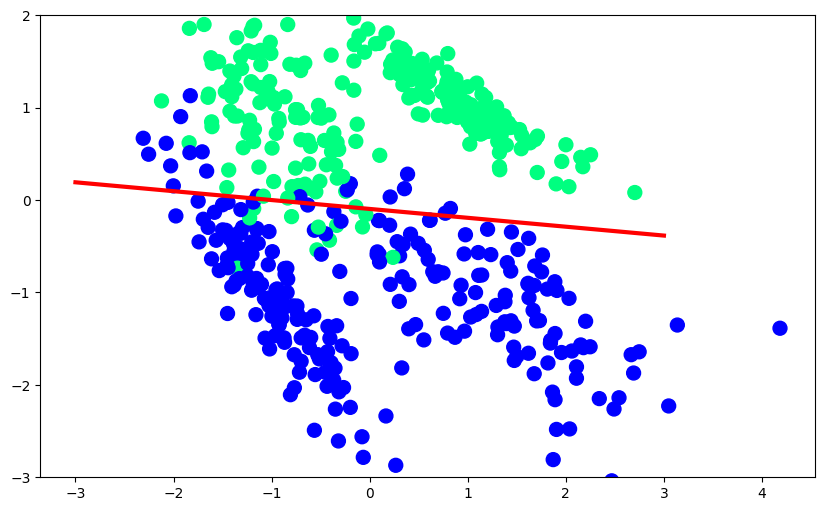

In [42]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

Perceptron trick using sigmoid function

### 6. Perceptron with Sigmoid (Logistic Regression style)
This section implements a variation of the perceptron trick using the Sigmoid function, which introduces a probabilistic approach to the updates.

In [43]:
def perceptron(X,y):
  X=np.insert(X,0,1,axis=1)
  weights= np.ones(X.shape[1])
  lr=0.1

  for i in range(1000):

    j=np.random.randint(X.shape[0])
    y_hat=sigmoid(np.dot(X[j],weights))

    weights = weights +lr *(y[j]-y_hat) * X[j]

  return weights[0],weights[1:]




In [44]:
def sigmoid(z):
  return 1/(1- np.exp(-z))


In [45]:
intercept,coef=perceptron(X,y)


In [46]:
m=(coef[0]/coef[1])
b=(intercept/coef[1])


In [47]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

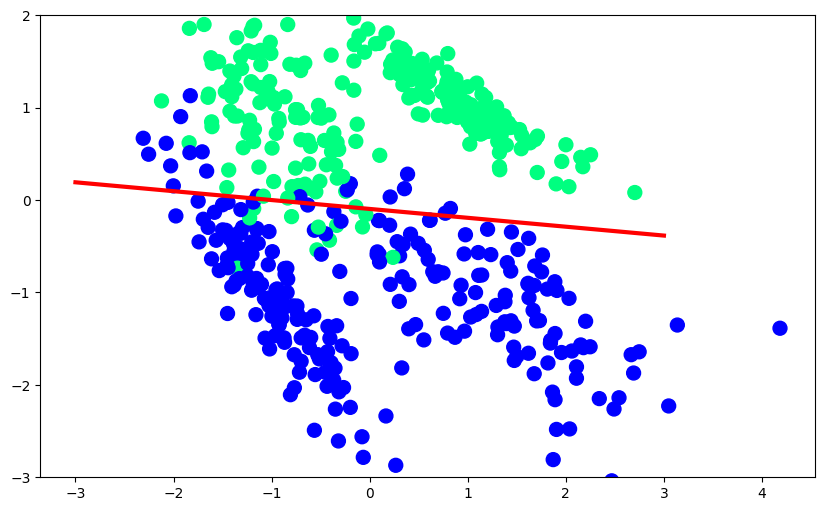

In [48]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

### 7. Scikit-Learn Logistic Regression
For comparison, we use the standard `LogisticRegression` implementation from Scikit-Learn to fit the same data.

In [49]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

### 8. Comparing Decision Boundaries
Finally, we calculate the decision boundaries for the different methods and plot them together to see how the custom implementations compare to the library standard.

In [50]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

In [51]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m*x_input + b

(-3.0, 2.0)

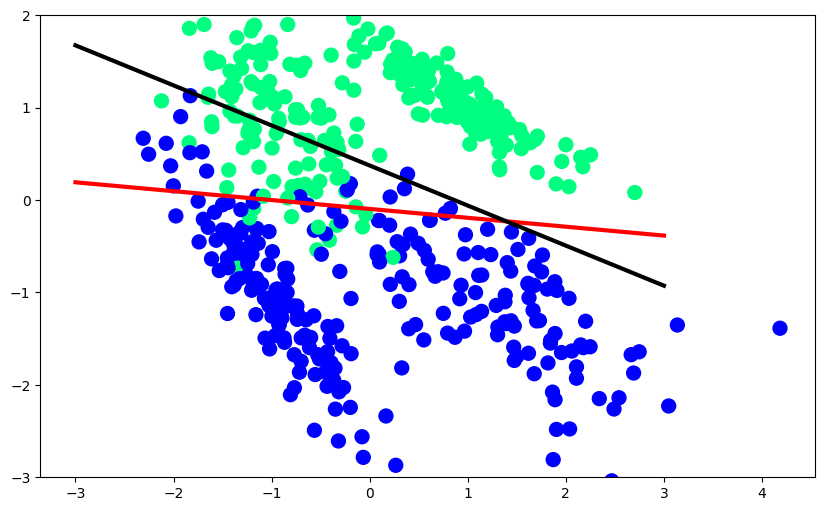

In [52]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

(-3.0, 2.0)

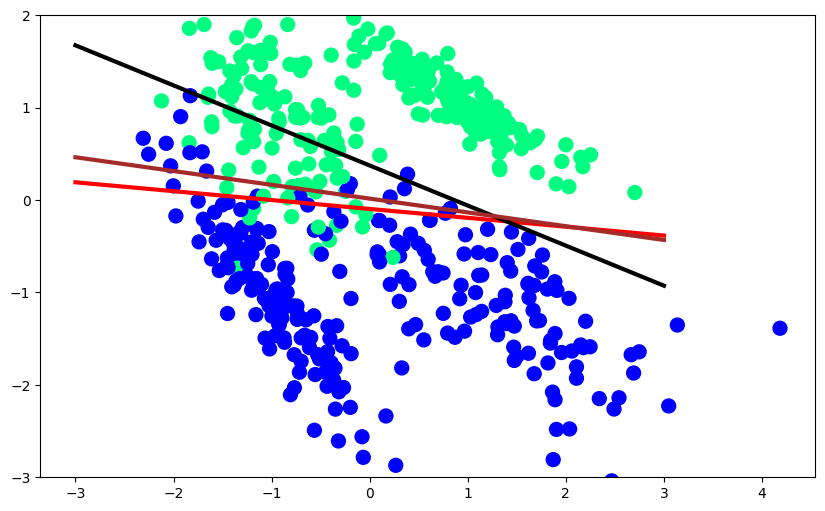

In [53]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

### 9. Performance Metrics Comparison
Now we will evaluate the accuracy of our three models: the basic Perceptron, the Sigmoid-based Perceptron, and Scikit-Learn's Logistic Regression.

In [54]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Helper to get predictions from our manual models
def get_predictions_step(X, intercept, coef):
    z = intercept + np.dot(X, coef)
    return np.array([1 if val > 0 else 0 for val in z])

def get_predictions_sigmoid(X, intercept, coef):
    z = intercept + np.dot(X, coef)
    return np.array([1 if (1/(1 + np.exp(-val))) > 0.5 else 0 for val in z])

# Predictions
y_pred_step = get_predictions_step(X, intercept_, coef_)
y_pred_sigmoid = get_predictions_sigmoid(X, intercept, coef)
y_pred_lor = lor.predict(X)

# Accuracy
print(f"Perceptron (Step) Accuracy: {accuracy_score(y, y_pred_step):.4f}")
print(f"Perceptron (Sigmoid) Accuracy: {accuracy_score(y, y_pred_sigmoid):.4f}")
print(f"Sklearn LogReg Accuracy: {accuracy_score(y, y_pred_lor):.4f}")

Perceptron (Step) Accuracy: 0.9400
Perceptron (Sigmoid) Accuracy: 0.8380
Sklearn LogReg Accuracy: 0.9380


### 10. Confusion Matrix Visualization
Visualizing the confusion matrices allows us to see the types of errors (False Positives vs False Negatives) each model makes.

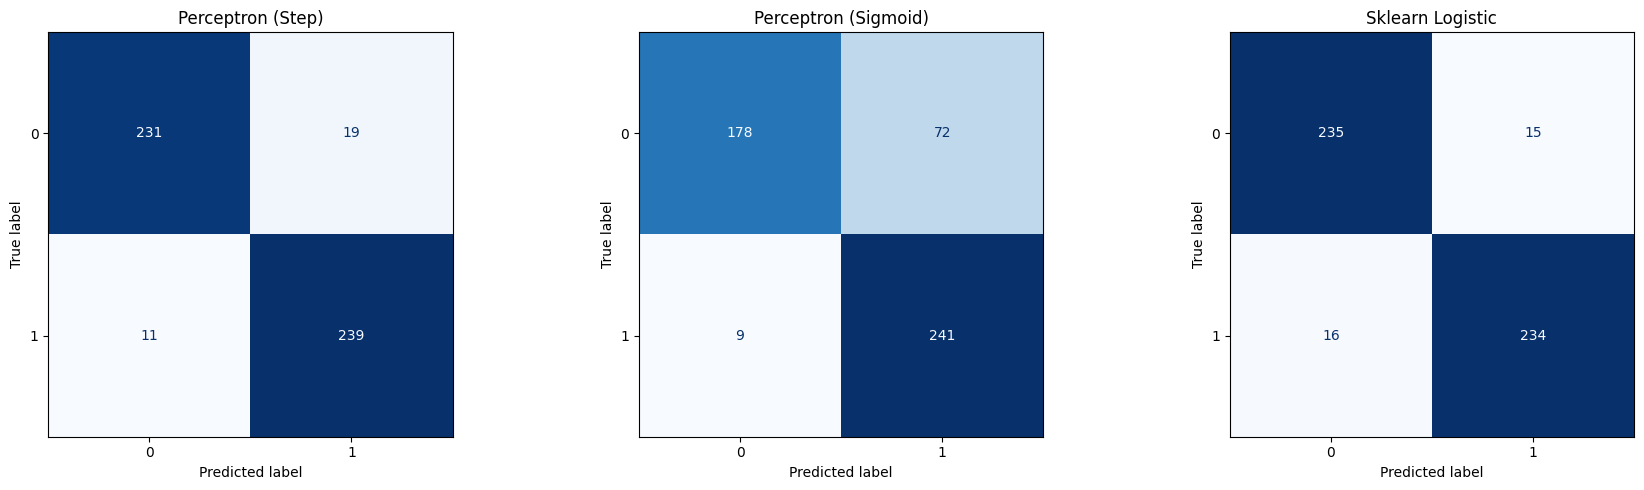

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    (y, y_pred_step, "Perceptron (Step)"),
    (y, y_pred_sigmoid, "Perceptron (Sigmoid)"),
    (y, y_pred_lor, "Sklearn Logistic")
]

for i, (y_true, y_pred, title) in enumerate(models):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(title)

plt.tight_layout()
plt.show()